In [1]:
# importing
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress


from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import rasterio
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl1020/lib/python3.8/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


### procedure

- Aiming for model of the form
$TWS^{i,t} = \gamma G_P^{i,t} + \pi P^{i,t} + \chi G_{P} \bar{P}^{i,t} + \theta T^{i,t} + \sigma^i + \tau^t + \epsilon $

- For each variable, need to load, aggregate to water-year, detrend, take absolute and standardized anomalies
- then need to convert to panel form

### load  GRACE

In [2]:
#data dirs
grace_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GRACE/'
gini_dir = 'dartfs-hpc/rc/lab/C/CMIG/clesk/projects/plcl/data/hydro-gini/'
cpc_dir =  '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/ppt/'
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'
fig_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/'

In [3]:
#open grace data, from https://www2.csr.utexas.edu/grace/RL06_mascons.html
grace = xr.open_dataset(grace_dir + 'CSR_GRACE_GRACE-FO_RL0603_Mascons_all-corrections.nc')

In [4]:
grace

<xarray.Dataset>
Dimensions:        (time: 248, timebound: 2, lon: 1440, lat: 720)
Coordinates:
  * time           (time) float32 107.0 129.5 227.5 ... 8.598e+03 8.628e+03
  * lon            (lon) float32 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
Dimensions without coordinates: timebound
Data variables:
    time_bounds    (time, timebound) float32 ...
    lwe_thickness  (time, lat, lon) float32 ...
Attributes: (12/59)
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    filename:                   netcdf/CSR_GRACE_GRACE-FO_RL0603_Mascons_all-...
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    title:                      CSR GRACE and GRACE-FO MASCON RL0603M
    subtitle:                   RL06.3 GRACE/GRACE-FO Total water storage wit...
    ...                         ...
    user_note_3:                Ellipsoidal correction has been applied. The ...
    user_note_4:                This GRACE-FO RL06.3 data is an updated versi...
    date_created:               2025-10-21T11:40:22Z
    variable:                   liquid water equivalent thickness
    label:                      RL0603rc24cE
    Mask:                       Global

### resample grace to water year

In [5]:
# aggregate to water-year
this_v_m_e_ds = grace
this_v_m_e_monthly = grace['lwe_thickness']

# northen hemisphere water-year  = oct->sep
# make northern hemisphere water year var:
#print('computing NH water year P, ET, Q.', flush=True)
nh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 10, this_v_m_e_ds.time.dt.year + 1)
this_v_m_e_monthly['water_year_nh'] = nh_wateryears

# southern hemisphere water year = jul->jun

# make s.h. water year
#print('computing SH water year P, ET, Q.', flush=True)
sh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 7, this_v_m_e_ds.time.dt.year + 1)
this_v_m_e_monthly['water_year_sh'] = sh_wateryears

# select data for northern hemisphere - I'm giving the equator to the North...
northern_hemi_latmask = this_v_m_e_monthly.lat>=0.0
northern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[northern_hemi_latmask])

# ... and for southern hemisphere
southern_hemi_latmask = this_v_m_e_monthly.lat<0.0
southern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[southern_hemi_latmask])

# aggregate each hemisphere to its respective water-year level:
print('computing hemispheres.', flush=True)
# northern
this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').mean(dim='time')

# southern
this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').mean(dim='time')

# merge north and southern hemispheres together into one water-year dataset:
print('merging hemispheres.', flush=True)

this_v_m_e_nhwy_sum = this_v_m_e_nhwy_sum.rename({'water_year_nh':'water_year'})
this_v_m_e_shwy_sum = this_v_m_e_shwy_sum.rename({'water_year_sh':'water_year'})

this_v_m_e_wateryear_sum = xr.merge([this_v_m_e_nhwy_sum, this_v_m_e_shwy_sum])
this_v_m_e_wateryear_sum = this_v_m_e_wateryear_sum.drop(['water_year'])

# add attrs
this_v_m_e_wateryear_sum['lwe_thickness'].attrs['units'] = 'mm per water-year'

gracewy = this_v_m_e_wateryear_sum
gracewy['water_year'] = np.arange(2002,2024)
gracewy = gracewy.sel(water_year= np.arange(2002,2023))
gatts = grace.attrs
gatts['aggregation'] = 'water-year mean'
gatts['notes'] = 'missing break in 2017-2018 means effective sample is 2003-2016 and 2019-2022 (18 years)'
gracewy.assign_attrs(grace.attrs);


computing hemispheres.
merging hemispheres.


In [277]:
# alternative water-year averaging approach using time coord shifting
def shift_time_by_months(time_array, months):
    return time_array + pd.DateOffset(months=months)

shifted_time = shift_time_by_months(grace['time'].to_index(), 3)

grace_shifted = grace.assign_coords(time=shifted_time)
gracewy2 = grace_shifted.resample(time='AS-JAN').mean()

shifted_time = shift_time_by_months(gracewy2['time'].to_index(), -3)
gracewy2 = gracewy2.assign_coords(time=shifted_time)
gracewy2['water_year'] = np.arange(2002,2024)


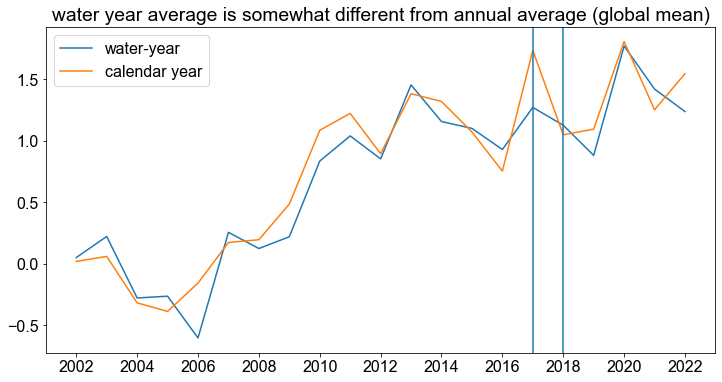

In [249]:
l1=plt.plot(np.arange(2002,2023),gracewy.sel(lon=slice(-60,65)).mean(['lon','lat']).lwe_thickness.values)
l2=plt.plot(np.arange(2002,2023),grace.sel(lon=slice(-60,65)).groupby('time.year').mean().mean(['lon','lat']).lwe_thickness.values)
plt.title('water year average is somewhat different from annual average (global mean)');
plt.xticks(np.arange(2002,2023,2))
plt.axvline(2017)
plt.axvline(2018)

plt.legend([l1[0],l2[0]],['water-year','calendar year'])

In [268]:
# water year means save:
gracewy.to_netcdf(save_dir+'GRACE_LWE_wateryear.nc')

### load and process CPC precip and temp

In [3]:
# load CPC daily precip
cpc = xr.open_mfdataset(cpc_dir + '*.nc')


In [73]:

# resample to monthly and trim to 2002-2022
pr_monthly = cpc.resample(time='M').sum()
pr_monthly = pr_monthly.sel(time=slice('2002-01-01','2022-12-31'))


In [75]:
# aggregate to water-year
this_v_m_e_ds = pr_monthly
this_v_m_e_monthly = pr_monthly.precip

# northen hemisphere water-year  = oct->sep
# make northern hemisphere water year var:
#print('computing NH water year P, ET, Q.', flush=True)
nh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 10, this_v_m_e_ds.time.dt.year + 1)
this_v_m_e_monthly['water_year_nh'] = nh_wateryears

# southern hemisphere water year = jul->jun

# make s.h. water year
#print('computing SH water year P, ET, Q.', flush=True)
sh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 7, this_v_m_e_ds.time.dt.year + 1)
this_v_m_e_monthly['water_year_sh'] = sh_wateryears

# select data for northern hemisphere - I'm giving the equator to the North...
northern_hemi_latmask = this_v_m_e_monthly.lat>=0.0
northern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[northern_hemi_latmask])

# ... and for southern hemisphere
southern_hemi_latmask = this_v_m_e_monthly.lat<0.0
southern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[southern_hemi_latmask])

# aggregate each hemisphere to its respective water-year level:
print('computing hemispheres.', flush=True)
# northern
this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').sum(dim='time')

# southern
this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').sum(dim='time')

# merge north and southern hemispheres together into one water-year dataset:
print('merging hemispheres.', flush=True)

this_v_m_e_nhwy_sum = this_v_m_e_nhwy_sum.rename({'water_year_nh':'water_year'})
this_v_m_e_shwy_sum = this_v_m_e_shwy_sum.rename({'water_year_sh':'water_year'})

this_v_m_e_wateryear_sum = xr.merge([this_v_m_e_nhwy_sum, this_v_m_e_shwy_sum])
this_v_m_e_wateryear_sum = this_v_m_e_wateryear_sum.drop(['water_year'])

# add attrs
this_v_m_e_wateryear_sum['precip'].attrs['units'] = 'mm per water-year'

prwy = this_v_m_e_wateryear_sum
prwy['water_year'] = np.arange(2002,2024)
pratts = pr_monthly.attrs
pratts['aggregation'] = 'water-year mean'
prwy.assign_attrs(pratts);

#trim off 2023
prwy = prwy.sel(water_year=prwy.water_year[:-1])

computing hemispheres.
merging hemispheres.


In [76]:
# now for temp, using tmean calculated from CPC (tmax+tmean)/2 by C. Callahan
cpc = xr.open_mfdataset('/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/tmean/1979-2022.nc')

# resample to monthly and trim to 2002-2022
t_monthly = cpc.resample(time='M').mean()
t_monthly = t_monthly.sel(time=slice('2002-01-01','2022-12-31'))

# aggregate to water-year
this_v_m_e_ds = t_monthly
this_v_m_e_monthly = t_monthly.tmean

# northen hemisphere water-year  = oct->sep
# make northern hemisphere water year var:
#print('computing NH water year P, ET, Q.', flush=True)
nh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 10, this_v_m_e_ds.time.dt.year + 1)
this_v_m_e_monthly['water_year_nh'] = nh_wateryears

# southern hemisphere water year = jul->jun

# make s.h. water year
#print('computing SH water year P, ET, Q.', flush=True)
sh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 7, this_v_m_e_ds.time.dt.year + 1)
this_v_m_e_monthly['water_year_sh'] = sh_wateryears

# select data for northern hemisphere - I'm giving the equator to the North...
northern_hemi_latmask = this_v_m_e_monthly.lat>=0.0
northern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[northern_hemi_latmask])

# ... and for southern hemisphere
southern_hemi_latmask = this_v_m_e_monthly.lat<0.0
southern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[southern_hemi_latmask])

# aggregate each hemisphere to its respective water-year level:
print('computing hemispheres.', flush=True)
# northern
this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').mean(dim='time')

# southern
this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').mean(dim='time')

# merge north and southern hemispheres together into one water-year dataset:
print('merging hemispheres.', flush=True)

this_v_m_e_nhwy_sum = this_v_m_e_nhwy_sum.rename({'water_year_nh':'water_year'})
this_v_m_e_shwy_sum = this_v_m_e_shwy_sum.rename({'water_year_sh':'water_year'})

this_v_m_e_wateryear_sum = xr.merge([this_v_m_e_nhwy_sum, this_v_m_e_shwy_sum])
this_v_m_e_wateryear_sum = this_v_m_e_wateryear_sum.drop(['water_year'])

# add attrs
this_v_m_e_wateryear_sum['tmean'].attrs['units'] = 'degrees C'

twy = this_v_m_e_wateryear_sum
twy['water_year'] = np.arange(2002,2023)
tatts = t_monthly.attrs
tatts['aggregation'] = 'water-year mean'
twy.assign_attrs(tatts);

# no need to trim off 2023 as ends in 2022


computing hemispheres.
merging hemispheres.


In [77]:
# calculate long term mean P for interaction
prwy_mean = prwy.mean('water_year')


In [78]:
prmhld = np.repeat(prwy_mean.precip.values[:, :, np.newaxis], 21, axis=2)



In [79]:
prwy_mean_ds = xr.DataArray(prmhld,coords={'lat':prwy_mean.lat,'lon':prwy_mean.lon,'water_year':np.arange(2002,2023)})
prwy_mean_ds = prwy_mean_ds.to_dataset(name='pr_mean')


In [297]:
#now interp grace to cpc grid 
gracewy_rs = gracewy.interp_like(prwy)

### Now detrend LWE, precip, and tmean to isolate IAV anomalies (Linear)

In [12]:
# wrap linear detrend
def detrend_dim(da, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim='water_year', deg=deg)
    fit = xr.polyval(da.water_year, p.polyfit_coefficients)
    return da - fit

# start to Theil-Sen version, but using linear for now
def TS_detrend(da, dim):
    
    X = data.year.values[:, np.newaxis]
    y = data.values[:, np.newaxis]
    est = TheilSenRegressor(random_state=42)
    est.fit(X,y)
    predicted = est.predict(X)
    return da-predicted

# Chris' temp data is in -180 to 180 lon coords, harmonize them to 0-360:
def flipLon360(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift


In [484]:
# detrend
prwy_detrend = detrend_dim(prwy.precip)
twy_detrend = detrend_dim(twy.tmean)
grace_detrend = detrend_dim(gracewy_rs.lwe_thickness)


In [501]:
# get into 0-360 lon coords
twy_detrend = flipLon360(twy_detrend)

### bring in annual GINI on daily precip
and take anoms

In [3]:
pr_gini_wy = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CPC_daily_pr_gini_water_year_2002-2022.nc')

In [542]:
pr_gini_wy_detrend = detrend_dim(pr_gini_wy.Pgini_wy)

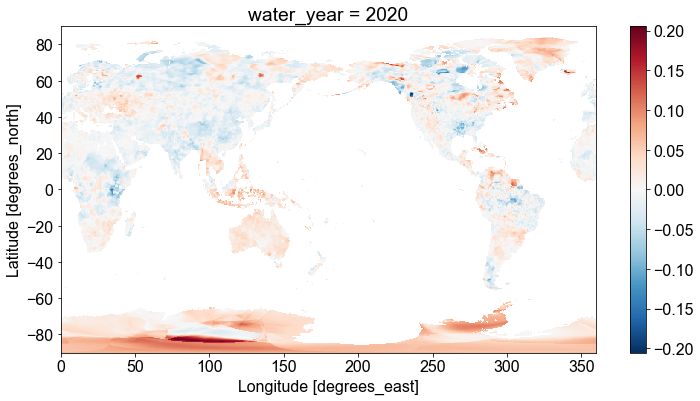

In [544]:
pr_gini_wy_detrend.sel(water_year=2020).plot()

### combine dataset, set lon extent to -60 to 65, send to DataFrame format with lon-lat indices, save

In [545]:
pexq_ds = xr.Dataset(data_vars={'LWE':grace_detrend,
                                'P':prwy_detrend,
                                'T':twy_detrend,
                                'Gp':pr_gini_wy.Pgini_wy,
                                'Gp_anoms':pr_gini_wy_detrend,
                                'Pmean':prwy_mean_ds.pr_mean},
                     coords={'lon':prwy_detrend.lon,'lat':prwy_detrend.lat,'water_year':prwy_detrend.water_year}
                    )


In [546]:
#load landmask, interp and apply
mask = xr.open_dataset(save_dir+'IMERG_land_sea_mask.nc')
mask = mask.interp_like(pexq_ds)
mask = mask.landseamask < 75
pexq_mask = pexq_ds.where(mask)

#set lat extent
pexq_mask = pexq_mask.sel(lat=slice(-55,70))

In [586]:
# also stdize anomalies
pexq_SD = pexq_ds.std(dim='water_year')
pexq_stdz = pexq_ds/pexq_SD

# this simple approach wrecks the Pmean, which is time invariant, so put it back:
pexq_stdz['Pmean'] = pexq_ds.Pmean

# mask and trim lats too:
pexq_stdz_mask = pexq_stdz.where(mask)
pexq_stdz_mask = pexq_stdz_mask.sel(lat=slice(-55,70))

In [549]:
#to df
pexq_mask_df = pexq_mask.to_dataframe()

# drop masked rows
pexq_mask_df = pexq_mask_df.dropna()

# add unique grid id
indices = [str(ind[1])+'_'+str(ind[2]) for ind in pexq_mask_df.index]
pexq_mask_df['gridindex'] = indices

# save
pexq_mask_df.to_csv(save_dir + 'pexq_df.csv')


In [593]:
#same for standardized, to df
pexq_stdz_mask_df = pexq_stdz_mask.to_dataframe()

# drop masked rows
pexq_stdz_mask_df = pexq_stdz_mask_df.dropna()

# add unique grid id
indices = [str(ind[1])+'_'+str(ind[2]) for ind in pexq_stdz_mask_df.index]
pexq_stdz_mask_df['gridindex'] = indices

#save
pexq_stdz_mask_df.to_csv(save_dir + 'pexq_std_df.csv')

In [538]:
prwy_mean_ds.sel(lon=slice(100.1,100.3),lat=45.25)

<xarray.Dataset>
Dimensions:     (lon: 1, water_year: 21)
Coordinates:
    lat         float64 45.25
  * lon         (lon) float32 100.2
  * water_year  (water_year) int64 2002 2003 2004 2005 ... 2019 2020 2021 2022
Data variables:
    pr_mean     (lon, water_year) float32 129.5 129.5 129.5 ... 129.5 129.5

### Add basin ID for clustering SE's:
hydroSHEDs

In [7]:
grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')
hshd = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/hydrosheds/hybas_au_lev01_v1c.shp')
#usgs = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/USGS_WBD/WBDHU2/WBDHU2.shp')

In [8]:
# geom functions
def flipLon(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = (dsshift.lon.values + 180) % 360 - 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

def transform_from_latlon(lat, lon):
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    trans = Affine.translation(lon[0], lat[0])
    scale = Affine.scale(lon[1] - lon[0], lat[1] - lat[0])
    return trans * scale

def flipLon360(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

import rasterio.features as features 

def rasterz(shapes, coords, fill=np.nan, **kwargs):
    """Rasterize a list of (geometry, fill_value) tuples onto the given
    xarray coordinates. This only works for 1d latitude and longitude
    arrays.
    """
    transform = transform_from_latlon(coords['lat'], coords['lon'])
    out_shape = (len(coords['lat']), len(coords['lon']))
    raster = features.rasterize(shapes, out_shape=out_shape,
                                fill=fill, transform=transform,
                                dtype=float, **kwargs)
    return xr.DataArray(raster, coords=coords, dims=('lat', 'lon'))


In [233]:
# rasterize basins
cpcflip = flipLon(cpc)
shapes = ((geom, 1) for geom in grdc_basins.geometry)
lons = cpcflip.lon
lats = cpcflip.lat

x_min, y_min, x_max, y_max = grdc_basins.total_bounds  
grid_resolution = 0.25
transform = transform_from_latlon(cpc.lon,cpc.lat)

# dictionary mapping river basin names onto integer IDs
basin_ids = dict(zip(grdc_basins["RIVER_BASI"],grdc_basins["MRBID"]))
basin_ids_rev = {v:k for k,v in basin_ids.items()}

# tuples mapping basin geometries onto those same IDs
basin_shapes = list(zip(grdc_basins["geometry"],grdc_basins["MRBID"].astype(int)))

basin_da = rasterz(basin_shapes,coords=dict(lat=lats,lon=lons))

basin_da = flipLon360(basin_da)


In [9]:
# load in the panel
pexq_df = pd.read_csv(save_dir + 'pexq_df.csv')


In [78]:
#merge basin_id into full df:
basin_lst = []
for ind in pexq_df.index:
    if ind % 1e5 == 0: print(ind)
    basin_id = basin_da.sel(lat=pexq_df.loc[ind].lat,lon=pexq_df.loc[ind].lon).values.item()
    basin_lst.append(basin_id)



0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000


In [79]:
pexq_df['basin_id'] = basin_lst

In [84]:
basin_df = pexq_df[['lat','lon','gridindex','basin_id']]

In [87]:
basin_df.to_csv(save_dir+'basin_id_df.csv')

In [92]:

pexqfilt = pexq_df[~np.isnan(pexq_df.basin_id)]

print(pexq_df.Pmean.min(),pexq_df.Pmean.max())
print(pexqfilt.Pmean.min(),pexqfilt.Pmean.max())



0.48672435 5294.9854
2.2685843 4787.654


### build panel for GPCP

In [ ]:
def pexqMerge(ds,varname,dfname,detrend=True,regrid=True,stdz=True):
    
    if detrend:
        print('detrending')
        dsdetrend = detrend_dim(ds[varname])
    else:
        dsdetrend = ds[varname]
        
    mask = xr.open_dataset(save_dir+'IMERG_land_sea_mask.nc')
    mask = mask.interp_like(ds)
    mask = mask.landseamask < 75
    dsdetrend = dsdetrend.where(mask)
    
    #interp to reference grid:
    if regrid:
        print('regridding')
        refgrd = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CPC_daily_pr_gini_water_year_2002-2022.nc')
        dsdetrend = dsdetrend.interp_like(refgrd.sel(water_year=refgrd.water_year[0]))
    
    ds_mask = dsdetrend.sel(lat=slice(-55,70))        
    
    #to df
    ds_mask_df = ds_mask.to_dataframe(name=dfname)

    # drop masked rows
    ds_mask_df = ds_mask_df.dropna()
    ds_mask_df = ds_mask_df.reset_index()

    # add unique grid id
    indices = [ds_mask_df.loc[ind].lat.astype('str')+'_'
               +ds_mask_df.loc[ind].lon.astype('str') for ind in ds_mask_df.index]
    ds_mask_df['gridindex'] = indices

    # also stdize anomalies
    if stdz:
        print('standardizing')
        ds_SD = ds_mask.std(dim='water_year')
        ds_stdz = ds_mask/ds_SD

        #to df
        ds_stdz_df = ds_stdz.to_dataframe(name=dfname)
        ds_stdz_df = ds_stdz_df.reset_index()

        # drop masked rows
        ds_stdz_df = ds_stdz_df.dropna()

        # add unique grid id
        indices = [ds_mask_df.loc[ind].lat.astype('str')+'_'
                   +ds_mask_df.loc[ind].lon.astype('str') for ind in ds_mask_df.index]
        ds_stdz_df['gridindex'] = indices
        
    else:
        ds_stdz_df = []
        
    return ds_mask_df,ds_stdz_df

In [ ]:
# load GPCP pr and pr gini data:
pr_gini_wy = xr.open_dataset(save_dir+'GPCP_daily_pr_gini_water_year_2002-2022.nc')
gpcp_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCP/v1.3_daily/'
gpcp_ds = xr.open_mfdataset(gpcp_dir+'gpcp_*.nc')

In [ ]:
# daily pr -> wy
# harmonize coord names and clear missing
gpcp_ds = gpcp_ds.rename({'longitude':'lon','latitude':'lat'})
gpcp_ds = gpcp_ds.precip.where(gpcp_ds.precip != -99999.0, 0)

#resample to monthly and agg to wy
pr_monthly = gpcp_ds.resample(time='M').sum()
prwy = wyAgg(pr_monthly,'sum')

prwy = prwy.sel(water_year=np.arange(2002,2023))

In [ ]:
# mean P
prmhld = np.repeat(prwy.mean(dim='water_year').precip.values[:, :, np.newaxis], 21, axis=2)
prwy_mean_ds = xr.DataArray(prmhld,coords={'lat':prwy.lat,'lon':prwy.lon,
                                           'water_year':np.arange(2002,2023)})
prwy_mean_ds = prwy_mean_ds.to_dataset(name='pr_mean')



In [ ]:
gp_df,gp_std = pexqMerge(pr_gini_wy,'Pgini_wy','Gp_GPCP')
prwy_df,prwy_std_df = pexqMerge(prwy,'precip','P_GPCP')
meanP_df,notdata = pexqMerge(prwy_mean_ds,'pr_mean','Pmean_GPCP',detrend=False)

In [ ]:
#load LWE and T data:
pexq_df = pd.read_csv(save_dir+'pexq_df.csv')
pexq_df = pexq_df[['lat','lon','LWE','gridindex','water_year','T']]

# add basin ids
basin_id_df = pd.read_csv(save_dir+'basin_id_df.csv')
pexq_df['basin_id'] = basin_id_df.basin_id

# create year-grid index to merge on for all variables
data_to_index = [gp_df,gp_std,prwy_df,prwy_std_df,meanP_df,pexq_df]
for d in data_to_index:
    d['yeargrid'] = d['water_year'].astype(str) + '_' + d['gridindex'].astype(str)

#merge unstandardized
merged_df = pexq_df.merge(gp_df[['yeargrid','Gp_GPCP']], on='yeargrid', how='outer')
merged_df = merged_df.merge(meanP_df[['yeargrid','Pmean_GPCP']], on='yeargrid', how='outer')
merged_df = merged_df.merge(prwy_df[['yeargrid','P_GPCP']],on='yeargrid', how='outer')
merged_df = merged_df.dropna()
merged_df.to_csv(save_dir+'pexq_df_GPCP.csv')

In [ ]:
#same for standardized
#load LWE and T data:
pexq_df = pd.read_csv(save_dir+'pexq_std_df.csv')
pexq_df = pexq_df[['lat','lon','LWE','gridindex','water_year','T']]
pexq_df['yeargrid'] = pexq_df['water_year'].astype(str) + '_' + pexq_df['gridindex'].astype(str)

# add basin ids
basin_id_df = pd.read_csv(save_dir+'basin_id_df.csv')
pexq_df['basin_id'] = basin_id_df.basin_id

#merge unstandardized
merged_std_df = pexq_df.merge(gp_std[['yeargrid','Gp_GPCP']], on='yeargrid', how='outer')
merged_std_df = merged_std_df.merge(meanP_df[['yeargrid','Pmean_GPCP']], on='yeargrid', how='outer')
merged_std_df = merged_std_df.merge(prwy_std_df[['yeargrid','P_GPCP']],on='yeargrid', how='outer')
merged_std_df = merged_std_df.dropna()
merged_std_df.to_csv(save_dir+'pexq_std_df_GPCP.csv')

In [ ]:
merged_df.to_csv(save_dir+'pexq_df_GPCP.csv')

### GPCP v3.3

In [ ]:
# load GPCP pr and pr gini data:
pr_gini_wy = xr.open_dataset(save_dir+'GPCPv3.3_daily_pr_gini_water_year_1998-2022.nc')
gpcp_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCP/v3.3_daily/'
gpcp_ds = xr.open_mfdataset(gpcp_dir+'*.nc')

In [ ]:
# harmonize coord names and clear missing
gpcp_ds = gpcp_ds.precip.where(gpcp_ds.precip != -99999.0, 0)
gpcp_ds = gpcp_ds.where(~gpcp_ds.isnull(), 0)


In [ ]:
# daily pr -> wy

#resample to monthly and agg to wy
pr_monthly = gpcp_ds.resample(time='M').sum()
prwy = wyAgg(pr_monthly,'sum')

prwy = prwy.sel(water_year=np.arange(2002,2023))

computing hemispheres.
merging hemispheres.


In [ ]:
# mean P
prmhld = np.repeat(prwy.mean(dim='water_year').precip.values[:, :, np.newaxis], 21, axis=2)
prwy_mean_ds = xr.DataArray(prmhld,coords={'lat':prwy.lat,'lon':prwy.lon,
                                           'water_year':np.arange(2002,2023)})
prwy_mean_ds = prwy_mean_ds.to_dataset(name='pr_mean')



In [ ]:
gp_df,gp_std = pexqMerge(pr_gini_wy,'Pgini_wy','Gp_GPCP')
prwy_df,prwy_std_df = pexqMerge(prwy,'precip','P_GPCP')
meanP_df,notdata = pexqMerge(prwy_mean_ds,'pr_mean','Pmean_GPCP',detrend=False)

detrending
regridding
standardizing
detrending
regridding
standardizing
regridding
standardizing


In [ ]:
#load LWE and T data:
pexq_df = pd.read_csv(save_dir+'pexq_df.csv')
pexq_df = pexq_df[['lat','lon','LWE','gridindex','water_year','T']]

# add basin ids
basin_id_df = pd.read_csv(save_dir+'basin_id_df.csv')
pexq_df['basin_id'] = basin_id_df.basin_id

# create year-grid index to merge on for all variables
data_to_index = [gp_df,gp_std,prwy_df,prwy_std_df,meanP_df,pexq_df]
for d in data_to_index:
    d['yeargrid'] = d['water_year'].astype(str) + '_' + d['gridindex'].astype(str)

#merge unstandardized
merged_df = pexq_df.merge(gp_df[['yeargrid','Gp_GPCP']], on='yeargrid', how='outer')
merged_df = merged_df.merge(meanP_df[['yeargrid','Pmean_GPCP']], on='yeargrid', how='outer')
merged_df = merged_df.merge(prwy_df[['yeargrid','P_GPCP']],on='yeargrid', how='outer')
merged_df = merged_df.dropna()
merged_df.to_csv(save_dir+'pexq_df_GPCPv3.3.csv')

### build panel for GPCC

In [ ]:
# load GPCP pr and pr gini data:
pr_gini_wy = xr.open_dataset(save_dir+'GPCC_daily_pr_gini_water_year_1982-2021.nc')
pr_gini_wy = pr_gini_wy.sel(water_year=np.arange(1982,2021))
pr_gini_wy = pr_gini_wy.sortby('lat')
gpcc_ds = xr.open_mfdataset('/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCC/v2022_daily/*.nc')


In [ ]:
# daily pr -> wy
# harmonize coord names and clear missing
gpcc_ds = flipLon360(gpcc_ds)
gpcc_ds = gpcc_ds.sortby('lat')

#resample to monthly and agg to wy
pr_monthly = gpcc_ds.resample(time='M').sum()
pr_monthly = pr_monthly.sel(time=slice('1982-01-01','2020-12-31'))
prwy = wyAgg(pr_monthly,'sum')
prwy = prwy.sel(water_year=np.arange(1982,2021))

computing hemispheres.
merging hemispheres.


In [ ]:
# mean P
prmhld = np.repeat(prwy.mean(dim='water_year').precip.values[:, :, np.newaxis], 21, axis=2)
prwy_mean_ds = xr.DataArray(prmhld,coords={'lat':prwy.lat,'lon':prwy.lon,
                                           'water_year':np.arange(1982,2023)})
prwy_mean_ds = prwy_mean_ds.to_dataset(name='pr_mean')



In [ ]:
gp_df,gp_std = pexqMerge(pr_gini_wy,'Pgini_wy','Gp_GPCC')
prwy_df,prwy_std_df = pexqMerge(prwy,'precip','P_GPCC')
meanP_df,notdata = pexqMerge(prwy_mean_ds,'pr_mean','Pmean_GPCC',detrend=False)

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl1020/lib/python3.8/site-packages/xarray/core/nputils.py:169: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


In [ ]:
#load LWE and T data:
pexq_df = pd.read_csv(save_dir+'pexq_df.csv')
pexq_df = pexq_df[['lat','lon','LWE','gridindex','water_year','T']]

# add basin ids
basin_id_df = pd.read_csv(save_dir+'basin_id_df.csv')
pexq_df['basin_id'] = basin_id_df.basin_id

# create year-grid index to merge on for all variables
data_to_index = [gp_df,gp_std,prwy_df,prwy_std_df,meanP_df,pexq_df]
for d in data_to_index:
    d['yeargrid'] = d['water_year'].astype(str) + '_' + d['gridindex'].astype(str)

#merge unstandardized
merged_df = pexq_df.merge(gp_df[['yeargrid','Gp_GPCC']], on='yeargrid', how='outer')
merged_df = merged_df.merge(meanP_df[['yeargrid','Pmean_GPCC']], on='yeargrid', how='outer')
merged_df = merged_df.merge(prwy_df[['yeargrid','P_GPCC']],on='yeargrid', how='outer')
merged_df = merged_df.dropna()
merged_df.to_csv(save_dir+'pexq_df_GPCC.csv')

In [ ]:
#same for standardized
#load LWE and T data:
pexq_df = pd.read_csv(save_dir+'pexq_std_df.csv')
pexq_df = pexq_df[['lat','lon','LWE','gridindex','water_year','T']]
pexq_df['yeargrid'] = pexq_df['water_year'].astype(str) + '_' + pexq_df['gridindex'].astype(str)

# add basin ids
basin_id_df = pd.read_csv(save_dir+'basin_id_df.csv')
pexq_df['basin_id'] = basin_id_df.basin_id

#merge unstandardized
merged_std_df = pexq_df.merge(gp_std[['yeargrid','Gp_GPCC']], on='yeargrid', how='outer')
merged_std_df = merged_std_df.merge(meanP_df[['yeargrid','Pmean_GPCC']], on='yeargrid', how='outer')
merged_std_df = merged_std_df.merge(prwy_std_df[['yeargrid','P_GPCC']],on='yeargrid', how='outer')
merged_std_df = merged_std_df.dropna()
merged_std_df.to_csv(save_dir+'pexq_std_df_GPCC_1982-2021.csv')

### ET data -- GLEAM 


In [3]:
gleam_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GLEAM/v3.8a/monthly/'
et_ds_gleam = xr.open_dataset(gleam_dir+'/E_1980-2022_GLEAM_v3.8a_MO.nc')

In [6]:
etwy = wyAgg(et_ds_gleam,'sum')
etwy = etwy.sel(water_year=np.arange(1981,2023))


computing hemispheres.
merging hemispheres.


In [15]:
et_df,et_std_df = pexqMerge(etwy,'E','ET_GLEAM')

detrending
regridding
standardizing


In [12]:
# load CPC daily precip
cpc = xr.open_mfdataset(cpc_dir + '*.nc')

# water year coords
cpc = cpc.sel(time=slice('1980-01-01','2023-12-31'))
nh,sh,nhmask,shmask = getHemiWY(cpc)
       

In [21]:
pr_monthly = cpc.resample(time='M').sum()
prwy = wyAgg(pr_monthly,'sum')

computing hemispheres.
merging hemispheres.


In [23]:
prwy = prwy.sel(water_year=np.arange(1981,2023))
prwy_df,prwy_std_df = pexqMerge(prwy,'precip','P_CPC')

detrending
regridding
standardizing


In [64]:
# mean P
prmhld = np.repeat(prwy.mean(dim='water_year').precip.values[:, :, np.newaxis], 2023-1981, axis=2)
prwy_mean_ds = xr.DataArray(prmhld,coords={'lat':prwy.lat,'lon':prwy.lon,
                                           'water_year':np.arange(1981,2023)})
prwy_mean_ds = prwy_mean_ds.to_dataset(name='pr_mean')

pmean_df,notdata = pexqMerge(prwy_mean_ds,'pr_mean','Pmean_CPC',detrend=False,regrid=False,stdz=False)

In [65]:
pmean_df

,lat,lon,water_year,Pmean_CPC,gridindex
0,-54.75,288.75,1981,473.711090,-54.75_288.75
1,-54.75,288.75,1982,473.711090,-54.75_288.75
2,-54.75,288.75,1983,473.711090,-54.75_288.75
3,-54.75,288.75,1984,473.711090,-54.75_288.75
4,-54.75,288.75,1985,473.711090,-54.75_288.75
...,...,...,...,...,...
2434105,69.75,336.75,2018,389.924744,69.75_336.75
2434106,69.75,336.75,2019,389.924744,69.75_336.75
2434107,69.75,336.75,2020,389.924744,69.75_336.75
2434108,69.75,336.75,2021,389.924744,69.75_336.75


In [33]:
# load GPCP pr and pr gini data:
pr_gini_wy = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/plcl/data/hydro-gini/annual_daily_pr_gini_CPC_1980-2020.nc')
pr_gini_wy = pr_gini_wy.rename({'year':'water_year'})

gp_df,gp_std = pexqMerge(pr_gini_wy,'pr_gini','Gp_CPC')


detrending
regridding


In [41]:
folder_path = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/tmean/'

# Create a list of filenames matching the desired range
file_names = [f'tmean.{year}.nc' for year in range(1980, 2024)]

# Create a list of full paths for each of the matching files
file_paths = [os.path.join(folder_path, fname) for fname in file_names]

# Open dataset
cpc_t = xr.open_mfdataset(file_paths, combine='by_coords')

# resample to monthly and aggregate water year
t_monthly = cpc_t.resample(time='M').mean()
twy = wyAgg(t_monthly,'mean')


computing hemispheres.
merging hemispheres.


In [ ]:
twy_df,twy_std_df = pexqMerge(twy,'tmean','T',regrid=False)

detrending


In [67]:

# create year-grid index to merge on for all variables
data_to_index = [gp_df,prwy_df,pmean_df,et_df,twy_df]
for d in data_to_index:
    d['yeargrid'] = d['water_year'].astype(str) + '_' + d['gridindex'].astype(str)

#merge unstandardized
merged_df = et_df.merge(gp_df[['yeargrid','Gp_CPC']], on='yeargrid', how='outer')
merged_df = merged_df.merge(pmean_df[['yeargrid','Pmean_CPC']], on='yeargrid', how='outer')
merged_df = merged_df.merge(prwy_df[['yeargrid','P_CPC']],on='yeargrid', how='outer')
merged_df = merged_df.merge(twy_df[['yeargrid','T']],on='yeargrid', how='outer')

merged_df = merged_df.dropna()




In [69]:
merged_df.to_csv(save_dir+'ET_df_1981-2022.csv')

In [ ]:
# add basin ids
basin_id_df = pd.read_csv(save_dir+'basin_id_df.csv')
pexq_df['basin_id'] = basin_id_df.basin_id





In [22]:
# daily pr -> wy
# harmonize coord names and clear missing
gpcp_ds = gpcp_ds.rename({'longitude':'lon','latitude':'lat'})
gpcp_ds = gpcp_ds.precip.where(gpcp_ds.precip != -99999.0, 0)

#resample to monthly and agg to wy
pr_monthly = gpcp_ds.resample(time='M').sum()
prwy = wyAgg(pr_monthly,'sum')

prwy = prwy.sel(water_year=np.arange(2002,2023))

In [23]:
# mean P
prmhld = np.repeat(prwy.mean(dim='water_year').precip.values[:, :, np.newaxis], 21, axis=2)
prwy_mean_ds = xr.DataArray(prmhld,coords={'lat':prwy.lat,'lon':prwy.lon,
                                           'water_year':np.arange(2002,2023)})
prwy_mean_ds = prwy_mean_ds.to_dataset(name='pr_mean')



In [25]:
gp_df,gp_std = pexqMerge(pr_gini_wy,'Pgini_wy','Gp_GPCP')
prwy_df,prwy_std_df = pexqMerge(prwy,'precip','P_GPCP')
meanP_df,notdata = pexqMerge(prwy_mean_ds,'pr_mean','Pmean_GPCP',detrend=False)

In [ ]:
Protocol: SFTP | Host: sftp://hydras.ugent.be | Port: 2225 | Username: gleamuser | Password: GLEAM4#h-cel_924

### merge ET data with multisource P, Pmean, Gp

In [156]:
et_df = pd.read_csv(save_dir + 'pexq_df_et.csv')
gpcc_df = pd.read_csv(save_dir+'pexq_df_GPCC.csv')
gpcp_df = pd.read_csv(save_dir+'pexq_df_GPCP.csv')

#gpcc_df = gpcc_df.rename(columns={'water_year_x':'water_year','lat_x':'lat','lon_x':'lon','gridindex_x':'gridindex'})

In [157]:
# create year-grid index to merge on for all variables
data_to_index = [et_df,gpcc_df,gpcp_df]
for d in data_to_index:
    d['yeargrid'] = d['water_year'].astype('int').astype(str) + '_' + d['gridindex'].astype(str)

In [160]:
#do merges and clean up
merged_df_gpcc = et_df.merge(gpcc_df[['yeargrid','Gp_GPCC','P_GPCC','Pmean_GPCC','basin_id']], on='yeargrid', how='outer')
merged_df_gpcp = et_df.merge(gpcp_df[['yeargrid','Gp_GPCP','P_GPCP','Pmean_GPCP','basin_id']],on='yeargrid', how='outer')


merged_df_gpcc = merged_df_gpcc.dropna()
merged_df_gpcp = merged_df_gpcp.dropna()

merged_df_gpcc.to_csv(save_dir+'pexq_df_ET_GPCC.csv')
merged_df_gpcp.to_csv(save_dir+'pexq_df_ET_GPCP.csv')

### from here analysis goes into R for FLE model:
see script - lesk+mankin_regressions.r


### calculate dry and wet days per year, for Fig. 1e:

### cpc dry/wet days

In [19]:
def getHemiWY(ds):
    
    ds_wy = ds
    
    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    nh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 10, ds.time.dt.year + 1)
    ds_wy['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 7, ds.time.dt.year + 1)
    ds_wy['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = ds_wy.lat>=0.0
    northern_hemi = ds_wy.sel(lat=ds_wy.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = ds_wy.lat<0.0
    southern_hemi = ds_wy.sel(lat=ds_wy.lat.values[southern_hemi_latmask])

    return northern_hemi,southern_hemi,northern_hemi_latmask,southern_hemi_latmask

In [10]:
# load CPC daily precip
cpc = xr.open_mfdataset(cpc_dir + '*.nc')

In [12]:
# water year coords
cpc = cpc.sel(time=slice('1980-01-01','2022-12-31'))
nh,sh,nhmask,shmask = getHemiWY(cpc)
       

In [213]:
# get 90th percentile of precip
cpcrc = cpc.chunk({'time':-1})
cpc95 = cpcrc.where(cpcrc.precip>0).precip.quantile(0.95,dim='time',skipna=True).compute()
cpc99 = cpcrc.where(cpcrc.precip>0).precip.quantile(0.99,dim='time',skipna=True).compute()



In [214]:
def wetDayAgg(nhwd,shwd):
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    
    # get # days above
    nhwd = (nhyr>p95nh).sum(dim='time')
    shwd = (shyr>p95sh).sum(dim='time')
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    
    #combine and store
    nhwd = xr.DataArray(nhwd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shwd = xr.DataArray(shwd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhwds = nhwd.to_dataset(name='wet_days')
    shwds = shwd.to_dataset(name='wet_days')
    return xr.merge([nhwds,shwds])

In [215]:
# set thresholds: 0.1mm for dry, 95th pctile for very wet
ddthresh = 0.1
p95nh = cpc95.sel(lat=cpc95.lat.values[cpc95.lat>=0.0])
p95sh = cpc95.sel(lat=cpc95.lat.values[cpc95.lat<0.0])
p99nh = cpc99.sel(lat=cpc99.lat.values[cpc99.lat>=0.0])
p99sh = cpc99.sel(lat=cpc99.lat.values[cpc99.lat<0.0])
#dd_hold = []
wd95_hold = []
wd99_hold = []

startyear=2002
endyear=2022

for i,yr in enumerate(range(startyear,endyear+1)):
    print(yr)
    #subset time
    nhyr = nh.sel(time=nh.time[nh.water_year_nh==yr])
    shyr = sh.sel(time=sh.time[sh.water_year_sh==yr])

    #dry days
    #nhdd = (nhyr['precip']<ddthresh).sum(dim='time')
    #shdd = (shyr['precip']<ddthresh).sum(dim='time')

    #wet days 95
    nhwd = (nhyr>p95nh).sum(dim='time')
    shwd = (shyr>p95sh).sum(dim='time')
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    
    #combine and store
    #nhdd = xr.DataArray(nhdd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    #shdd = xr.DataArray(shdd,coords={'lat':shyr.lat,'lon':shyr.lon})
    #nhdds = nhdd.to_dataset(name='dry_days')
    #shdds = shdd.to_dataset(name='dry_days')
    #dd_hold.append(xr.merge([nhdds,shdds]))
    
    nhwd = xr.DataArray(nhwd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shwd = xr.DataArray(shwd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhwds = nhwd.to_dataset(name='wet_days_95')
    shwds = shwd.to_dataset(name='wet_days_95')
    wd95_hold.append(xr.merge([nhwds,shwds]))
    
    #wet days 99
    nhwd = (nhyr>p99nh).sum(dim='time')
    shwd = (shyr>p99sh).sum(dim='time')
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip

    nhwd = xr.DataArray(nhwd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shwd = xr.DataArray(shwd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhwds = nhwd.to_dataset(name='wet_days_99')
    shwds = shwd.to_dataset(name='wet_days_99')
    wd99_hold.append(xr.merge([nhwds,shwds]))
    
    

2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022


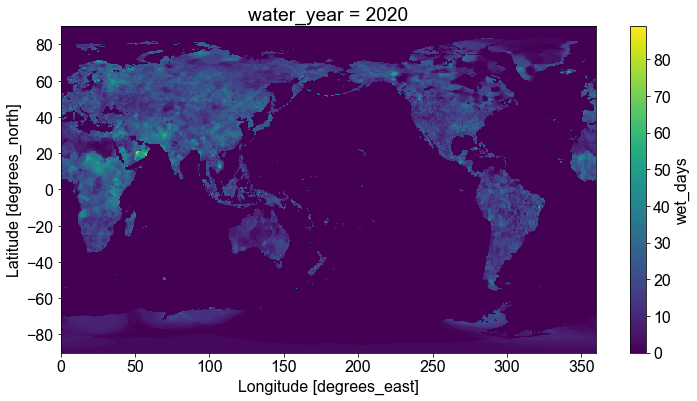

In [69]:
#assemble dataset

#dry days
dd_cpc = xr.concat(dd_hold,dim='water_year')
dd_cpc = dd_cpc.assign_coords({'water_year':np.arange(startyear,endyear+1)})

dd_cpc = dd_cpc.assign_attrs({'source':'https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-daily/',
                   'origin':'GPCP DAILY V1.3',
                   'index':'water-year dry days (<0.1mm/d), 2002-2022'})


In [219]:

#wet days 95th
wd95 = xr.concat(wd95_hold,dim='water_year')
wd95 = wd95.assign_coords({'water_year':np.arange(startyear,endyear+1)})

wd95 = wd95.assign_attrs({'source':'https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-daily/',
                   'origin':'GPCP DAILY V1.3',
                   'index':'water-year wet days (>95th local percentile of nonzero precip days per year), 2002-2022'})


#wet days 95th
wd99 = xr.concat(wd99_hold,dim='water_year')
wd99 = wd99.assign_coords({'water_year':np.arange(startyear,endyear+1)})

wd99 = wd99.assign_attrs({'source':'https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-daily/',
                   'origin':'GPCP DAILY V1.3',
                   'index':'water-year wet days (>99th local percentile of nonzero precip days per year), 2002-2022'})




In [98]:
pr_gini_wy = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CPC_daily_pr_gini_water_year_2002-2022.nc')


In [220]:
#set up rainfall metrics dataset:
twyll = flipLon360(twy)
gp_detrend = detrend_dim(pr_gini_wy.Pgini_wy)
wd95_detrend = detrend_dim(wd95.wet_days_95)
wd99_detrend = detrend_dim(wd99.wet_days_99)
dd_detrend = detrend_dim(dd_cpc.dry_days)
t_detrend = detrend_dim(twyll.tmean)
p_detrend = detrend_dim(prwy.precip)

metrics_ds = xr.Dataset(data_vars={'Gp':gp_detrend,
                                'P':p_detrend,
                                'T':t_detrend,
                                'DD':dd_detrend,
                                'WD95':wd95_detrend,
                                'WD99':wd99_detrend,                                
                                'Pmean':prwy_mean_ds.pr_mean},
                     coords={'lon':prwy.lon,'lat':prwy.lat,'water_year':prwy.water_year}
                    )


In [221]:
#load landmask, interp and apply
mask = xr.open_dataset(save_dir+'IMERG_land_sea_mask.nc')
mask = mask.interp_like(metrics_ds)
mask = mask.landseamask < 75
metrics_mask = metrics_ds.where(mask)

#set lat extent
metrics_mask = metrics_mask.sel(lat=slice(-55,70))

In [222]:
metrics_df = metrics_mask.to_dataframe()

# drop masked rows
metrics_df = metrics_df.dropna()

# add unique grid id
indices = [str(ind[1])+'_'+str(ind[2]) for ind in metrics_df.index]
metrics_df['gridindex'] = indices

#save
metrics_df.to_csv(save_dir+'metrics_df.csv')

In [223]:
# also stdize anomalies
metrics_SD = metrics_mask.std(dim='water_year')
metrics_stdz = metrics_mask/metrics_SD

# this simple approach wrecks the Pmean, which is time invariant, so put it back:
metrics_stdz['Pmean'] = metrics_mask.Pmean

# mask and trim lats too:
metrics_stdz_mask = metrics_stdz.where(mask)
metrics_stdz_mask = metrics_stdz_mask.sel(lat=slice(-55,70))
                                                    
#to df
metrics_std_df = metrics_stdz_mask.to_dataframe()

# drop masked rows
matrics_std_df = metrics_std_df.dropna()

# add unique grid id
indices = [str(ind[1])+'_'+str(ind[2]) for ind in metrics_std_df.index]
metrics_std_df['gridindex'] = indices

# save
metrics_std_df.to_csv(save_dir + 'metrics_std_df.csv')


### GPCC dry/wet days

In [19]:
def getHemiWY(ds):
    
    ds_wy = ds
    
    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    nh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 10, ds.time.dt.year + 1)
    ds_wy['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 7, ds.time.dt.year + 1)
    ds_wy['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = ds_wy.lat>=0.0
    northern_hemi = ds_wy.sel(lat=ds_wy.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = ds_wy.lat<0.0
    southern_hemi = ds_wy.sel(lat=ds_wy.lat.values[southern_hemi_latmask])

    return northern_hemi,southern_hemi,northern_hemi_latmask,southern_hemi_latmask

def wetDayAgg(nhwd,shwd):
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    
    # get # days above
    nhwd = (nhyr>p95nh).sum(dim='time')
    shwd = (shyr>p95sh).sum(dim='time')
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    
    #combine and store
    nhwd = xr.DataArray(nhwd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shwd = xr.DataArray(shwd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhwds = nhwd.to_dataset(name='wet_days')
    shwds = shwd.to_dataset(name='wet_days')
    return xr.merge([nhwds,shwds])

In [7]:
# load GPCP pr and pr gini data:
#pr_gini_wy = xr.open_dataset(save_dir+'GPCC_daily_pr_gini_water_year_1982-2021.nc')
#pr_gini_wy = pr_gini_wy.sel(water_year=np.arange(1982,2021))
#pr_gini_wy = pr_gini_wy.sortby('lat')
gpcc_ds = xr.open_mfdataset('/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCC/v2022_daily/*.nc')


In [18]:
# already have Gp, T and P, just need DD and WD

#get percentiles
gpcc_ds = gpcc_ds.sel(time=slice('2002-01-01','2022-12-31'))
nh,sh,nhmask,shmask = getHemiWY(gpcc_ds)

# get 95/99th percentile of precip
gpccrc = gpcc_ds.chunk({'time':-1})
gpcc95 = gpccrc.where(gpccrc.precip>0).precip.quantile(0.95,dim='time',skipna=True).compute()
gpcc99 = gpccrc.where(gpccrc.precip>0).precip.quantile(0.99,dim='time',skipna=True).compute()


In [32]:
# set thresholds: 0.1mm for dry, 95th pctile for very wet
ddthresh = 0.1
p95nh = gpcc95.sel(lat=gpcc95.lat.values[gpcc95.lat>=0.0])
p95sh = gpcc95.sel(lat=gpcc95.lat.values[gpcc95.lat<0.0])
p99nh = gpcc99.sel(lat=gpcc99.lat.values[gpcc99.lat>=0.0])
p99sh = gpcc99.sel(lat=gpcc99.lat.values[gpcc99.lat<0.0])

dd_hold = []
wd95_hold = []
wd99_hold = []

startyear=2002
endyear=2020

for i,yr in enumerate(range(startyear,endyear+1)):
    print(yr)
    #subset time
    nhyr = nh.sel(time=nh.time[nh.water_year_nh==yr])
    shyr = sh.sel(time=sh.time[sh.water_year_sh==yr])

    #dry days
    nhdd = (nhyr['precip']<ddthresh).sum(dim='time')
    shdd = (shyr['precip']<ddthresh).sum(dim='time')

    #wet days 95
    nhwd = (nhyr>p95nh).sum(dim='time')
    shwd = (shyr>p95sh).sum(dim='time')
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    
    
    nhdd = xr.DataArray(nhdd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shdd = xr.DataArray(shdd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhdds = nhdd.to_dataset(name='dry_days')
    shdds = shdd.to_dataset(name='dry_days')
    dd_hold.append(xr.merge([nhdds,shdds]))
    
    nhwd = xr.DataArray(nhwd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shwd = xr.DataArray(shwd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhwds = nhwd.to_dataset(name='wet_days_95')
    shwds = shwd.to_dataset(name='wet_days_95')
    wd95_hold.append(xr.merge([nhwds,shwds]))
    
    #wet days 99
    nhwd = (nhyr>p99nh).sum(dim='time')
    shwd = (shyr>p99sh).sum(dim='time')
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip

    nhwd = xr.DataArray(nhwd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shwd = xr.DataArray(shwd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhwds = nhwd.to_dataset(name='wet_days_99')
    shwds = shwd.to_dataset(name='wet_days_99')
    wd99_hold.append(xr.merge([nhwds,shwds]))
    
    

2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020


In [40]:
# assemble datsets
dd_gpcc = xr.concat(dd_hold,dim='water_year')
dd_gpcc = dd_gpcc.assign_coords({'water_year':np.arange(startyear,endyear+1)})

#wet days 95th
wd95 = xr.concat(wd95_hold,dim='water_year')
wd95 = wd95.assign_coords({'water_year':np.arange(startyear,endyear+1)})

#wet days 95th
wd99 = xr.concat(wd99_hold,dim='water_year')
wd99 = wd99.assign_coords({'water_year':np.arange(startyear,endyear+1)})


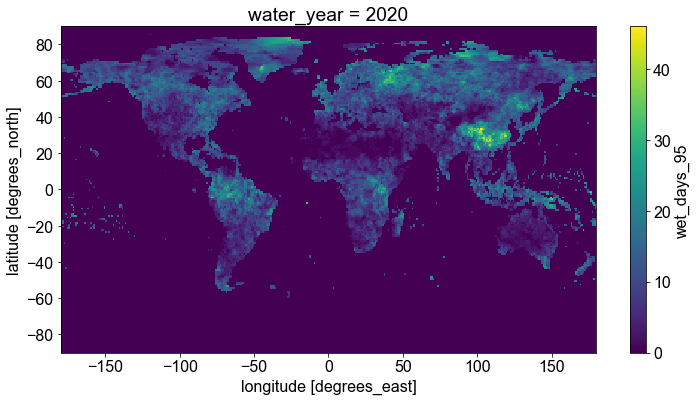

In [45]:
wd95.sel(water_year=2020).wet_days_95.plot()

In [50]:
# send datasets to df
dd_df,dd_std_df = pexqMerge(dd_gpcc,'dry_days','DD')

wd95_df,wd95_std_df = pexqMerge(wd95,'wet_days_95','WD95')
wd99_df,wd99_std_df = pexqMerge(wd99,'wet_days_99','WD99')


detrending
regridding
standardizing
detrending
regridding
standardizing


### GPCP dry/wet days

In [65]:
def getHemiWY(ds):
    
    ds_wy = ds
    
    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    nh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 10, ds.time.dt.year + 1)
    ds_wy['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 7, ds.time.dt.year + 1)
    ds_wy['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = ds_wy.lat>=0.0
    northern_hemi = ds_wy.sel(lat=ds_wy.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = ds_wy.lat<0.0
    southern_hemi = ds_wy.sel(lat=ds_wy.lat.values[southern_hemi_latmask])

    return northern_hemi,southern_hemi,northern_hemi_latmask,southern_hemi_latmask

def wetDayAgg(nhwd,shwd):
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    
    # get # days above
    nhwd = (nhyr>p95nh).sum(dim='time')
    shwd = (shyr>p95sh).sum(dim='time')
    nhwd = nhwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    shwd = shwd.drop(['water_year_sh','water_year_nh','quantile']).precip
    
    #combine and store
    nhwd = xr.DataArray(nhwd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shwd = xr.DataArray(shwd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhwds = nhwd.to_dataset(name='wet_days')
    shwds = shwd.to_dataset(name='wet_days')
    return xr.merge([nhwds,shwds])

In [67]:
# load GPCP pr and pr gini data:
#pr_gini_wy = xr.open_dataset(save_dir+'GPCP_daily_pr_gini_water_year_2002-2022.nc')
gpcp_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCP/v1.3_daily/'
gpcp_ds = xr.open_mfdataset(gpcp_dir+'gpcp_*.nc')

In [68]:
# daily pr -> wy
# harmonize coord names and clear missing
gpcp_ds = gpcp_ds.rename({'longitude':'lon','latitude':'lat'})
gpcp_ds = gpcp_ds.precip.where(gpcp_ds.precip != -99999.0, 0)



In [71]:
# already have Gp, T and P, just need DD and WD

#get percentiles
gpcp_ds = gpcp_ds.sel(time=slice('2002-01-01','2022-12-31'))
nh,sh,nhmask,shmask = getHemiWY(gpcp_ds)

# get 95/99th percentile of precip
gpcprc = gpcp_ds.chunk({'time':-1})
gpcp95 = gpcprc.where(gpcprc>0).quantile(0.95,dim='time',skipna=True).compute()
gpcp99 = gpcprc.where(gpcprc>0).quantile(0.99,dim='time',skipna=True).compute()


In [80]:
gpcp_ds

<xarray.DataArray 'precip' (time: 7670, lat: 180, lon: 360)>
dask.array<getitem, shape=(7670, 180, 360), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat            (lat) float32 -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon            (lon) float32 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * time           (time) datetime64[ns] 2002-01-01 2002-01-02 ... 2022-12-31
    water_year_nh  (time) int64 2002 2002 2002 2002 2002 ... 2023 2023 2023 2023
    water_year_sh  (time) int64 2002 2002 2002 2002 2002 ... 2023 2023 2023 2023
Attributes:
    long_name:      NOAA Climate Data Record (CDR) of Daily GPCP Satellite-Ga...
    standard_name:  lwe_precipitation_rate
    units:          mm/day
    valid_range:    [  0. 100.]
    cell_methods:   area: mean time: mean

In [81]:
# set thresholds: 0.1mm for dry, 95th pctile for very wet
ddthresh = 0.1
p95nh = gpcp95.sel(lat=gpcp95.lat.values[gpcp95.lat>=0.0])
p95sh = gpcp95.sel(lat=gpcp95.lat.values[gpcp95.lat<0.0])
p99nh = gpcp99.sel(lat=gpcp99.lat.values[gpcp99.lat>=0.0])
p99sh = gpcp99.sel(lat=gpcp99.lat.values[gpcp99.lat<0.0])

#dd_hold = []
#wd95_hold = []
#wd99_hold = []

startyear=2021
endyear=2022

for i,yr in enumerate(range(startyear,endyear+1)):
    print(yr)
    #subset time
    nhyr = nh.sel(time=nh.time[nh.water_year_nh==yr])
    shyr = sh.sel(time=sh.time[sh.water_year_sh==yr])

    #dry days
    nhdd = (nhyr<ddthresh).sum(dim='time')
    shdd = (shyr<ddthresh).sum(dim='time')

    #wet days 95
    nhwd = (nhyr>p95nh).sum(dim='time')
    shwd = (shyr>p95sh).sum(dim='time')
    nhwd = nhwd.drop(['quantile'])
    shwd = shwd.drop(['quantile'])
    
    
    nhdd = xr.DataArray(nhdd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shdd = xr.DataArray(shdd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhdds = nhdd.to_dataset(name='dry_days')
    shdds = shdd.to_dataset(name='dry_days')
    dd_hold.append(xr.merge([nhdds,shdds]))
    
    nhwd = xr.DataArray(nhwd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shwd = xr.DataArray(shwd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhwds = nhwd.to_dataset(name='wet_days_95')
    shwds = shwd.to_dataset(name='wet_days_95')
    wd95_hold.append(xr.merge([nhwds,shwds]))
    
    #wet days 99
    nhwd = (nhyr>p99nh).sum(dim='time')
    shwd = (shyr>p99sh).sum(dim='time')
    nhwd = nhwd.drop(['quantile'])
    shwd = shwd.drop(['quantile'])

    nhwd = xr.DataArray(nhwd,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shwd = xr.DataArray(shwd,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhwds = nhwd.to_dataset(name='wet_days_99')
    shwds = shwd.to_dataset(name='wet_days_99')
    wd99_hold.append(xr.merge([nhwds,shwds]))
    
    

2021
2022


In [82]:
len(wd99_hold)

21

In [83]:
startyear = 2002
endyear = 2022
# assemble datsets
dd_gpcp = xr.concat(dd_hold,dim='water_year')
dd_gpcp = dd_gpcp.assign_coords({'water_year':np.arange(startyear,endyear+1)})

#wet days 95th
wd95 = xr.concat(wd95_hold,dim='water_year')
wd95 = wd95.assign_coords({'water_year':np.arange(startyear,endyear+1)})

#wet days 95th
wd99 = xr.concat(wd99_hold,dim='water_year')
wd99 = wd99.assign_coords({'water_year':np.arange(startyear,endyear+1)})


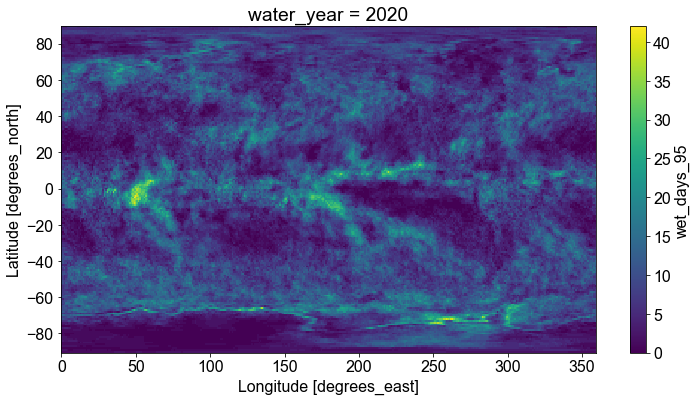

In [84]:
wd95.sel(water_year=2020).wet_days_95.plot()

In [ ]:
# send datasets to df
dd_df,dd_std_df = pexqMerge(dd_gpcp,'dry_days','DD')

wd95_df,wd95_std_df = pexqMerge(wd95,'wet_days_95','WD95')
wd99_df,wd99_std_df = pexqMerge(wd99,'wet_days_99','WD99')


detrending
regridding
standardizing


In [ ]:
#merge into full df
df_gpcp = pd.read_csv(save_dir+'pexq_std_df_GPCP.csv')

# create year-grid index to merge on for all variables
data_to_index = [dd_std_df,wd95_std_df,wd99_std_df]
for d in data_to_index:
    d['yeargrid'] = d['water_year'].astype(str) + '_' + d['gridindex'].astype(str)

In [ ]:
merged_df = df_gpcp.merge(dd_std_df[['yeargrid','DD']], on='yeargrid', how='outer')
merged_df = merged_df.merge(wd95_std_df[['yeargrid','WD95']], on='yeargrid', how='outer')
merged_df = merged_df.merge(wd99_std_df[['yeargrid','WD99']], on='yeargrid', how='outer')
merged_df = merged_df.dropna()
merged_df.to_csv(save_dir+'metrics_std_df_GPCP.csv')